<a href="https://colab.research.google.com/github/NikethnaSri-AI/Aanseaa_Technologies_Internship/blob/main/glove_character_level_transformer_spelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization
import os
import matplotlib.pyplot as plt

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip # Download the file
!unzip glove.6B.zip

--2024-12-11 10:13:56--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2024-12-11 10:13:57--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2024-12-11 10:13:58--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
def load_glove_embeddings(filepath):
    embeddings_index = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.array(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

glove_embeddings = load_glove_embeddings('glove.6B.100d.txt')

In [ ]:
with open('30000.txt', 'r') as file:
    words = file.read().splitlines()

words = [word.strip() for word in words]
print(f"Loaded {len(words)} words.")
print(words[:5])

Loaded 30000 words.
['the', 'of', 'and', 'to', 'a']


In [ ]:
df = pd.DataFrame(words, columns=['correctly_spelled'])
print(df.head())

  correctly_spelled
0               the
1                of
2               and
3                to
4                 a


In [ ]:
def generate_misspelling(word):
    if len(word) < 3:
        return word
    misspelling_type = random.choice(['transpose', 'insert', 'delete', 'substitute'])
    if misspelling_type == 'transpose' and len(word) > 2:
        idx = random.randint(0, len(word)-2)
        return word[:idx] + word[idx+1] + word[idx] + word[idx+2:]
    elif misspelling_type == 'insert':
        idx = random.randint(0, len(word)-1)
        char = random.choice('abcdefghijklmnopqrstuvwxyz')
        return word[:idx] + char + word[idx:]
    elif misspelling_type == 'delete':
        idx = random.randint(0, len(word)-1)
        return word[:idx] + word[idx+1:]
    elif misspelling_type == 'substitute':
        idx = random.randint(0, len(word)-1)
        char = random.choice('abcdefghijklmnopqrstuvwxyz')
        return word[:idx] + char + word[idx+1:]
    return word

df['misspelled'] = df['correctly_spelled'].apply(generate_misspelling)
print(df.head(30))

   correctly_spelled misspelled
0                the       sthe
1                 of         of
2                and       apnd
3                 to         to
4                  a          a
5                 in         in
6                for        dor
7                 is         is
8                 on         on
9               that      thajt
10                by         by
11              this       shis
12              with      witwh
13                 i          i
14               you        yor
15                it         it
16               not        nct
17                or         or
18                be         be
19               are        ari
20              from        frm
21                at         at
22                as         as
23              your      yjour
24               all       alvl
25              have       havx
26               new         nw
27              more        moe
28                an         an
29               was        waz


In [ ]:
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(df['correctly_spelled'].tolist() + df['misspelled'].tolist())
vocab_size = len(tokenizer.word_index) + 1  # Adding 1 for padding token
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 27


In [ ]:
embedding_dim = 100  # GloVe 100-dimensional embeddings
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Map the words in the tokenizer's vocabulary to their corresponding GloVe vectors
for word, i in tokenizer.word_index.items():
    if i < vocab_size:  # Make sure we do not exceed the vocab size
        embedding_vector = glove_embeddings.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [ ]:
X = tokenizer.texts_to_sequences(df['misspelled'].tolist())
y = tokenizer.texts_to_sequences(df['correctly_spelled'].tolist())

max_len = 20
X_pad = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')
y_pad = pad_sequences(y, maxlen=max_len, padding='post', truncating='post')

# One-hot encode y
y_one_hot = to_categorical(y_pad, num_classes=vocab_size)


In [ ]:
tokenizer.word_index

{'e': 1,
 'a': 2,
 'i': 3,
 's': 4,
 'r': 5,
 'n': 6,
 't': 7,
 'o': 8,
 'l': 9,
 'c': 10,
 'd': 11,
 'm': 12,
 'u': 13,
 'p': 14,
 'g': 15,
 'h': 16,
 'b': 17,
 'y': 18,
 'f': 19,
 'v': 20,
 'w': 21,
 'k': 22,
 'x': 23,
 'z': 24,
 'j': 25,
 'q': 26}

In [ ]:
X_pad.shape

(30000, 20)

In [ ]:
y_pad.shape

(30000, 20)

In [ ]:
y_one_hot.shape

(30000, 20, 27)

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into 10% test and 90% train + validation
X_train_val, X_test, y_train_val, y_test = train_test_split(X_pad, y_one_hot, test_size=0.1, random_state=42)

# Further split the 90% (train + validation) into train and validation sets (e.g., 80% train and 10% validation)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)


(24300, 20)
(24300, 20, 27)
(2700, 20)
(2700, 20, 27)
(3000, 20)
(3000, 20, 27)


In [ ]:
print(df.shape)

(30000, 2)


In [ ]:
class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, embed_dim):
        super(PositionalEncoding, self).__init__()
        self.max_len = max_len
        self.embed_dim = embed_dim

    def get_angles(self, pos, i):
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(self.embed_dim))
        return pos * angle_rates

    def call(self, inputs):
        position = np.arange(self.max_len)[:, np.newaxis]
        angle_rads = self.get_angles(position, np.arange(self.embed_dim)[np.newaxis, :])

        # Apply sine to even indices in the array; 2i
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

        # Apply cosine to odd indices in the array; 2i+1
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = angle_rads[np.newaxis, ...]

        return inputs + tf.cast(pos_encoding, dtype=tf.float32)

In [ ]:
inputs = layers.Input(shape=(max_len,))

# Embedding Layer using pre-trained GloVe embeddings
embeddings = layers.Embedding(input_dim=vocab_size, output_dim=100, input_length=max_len, weights=[embedding_matrix], trainable=True)(inputs)

# Apply Positional Encoding
encoded_embeddings = PositionalEncoding(max_len=max_len, embed_dim=100)(embeddings)

# First Multi-Head Attention Layer
attention_output1 = layers.MultiHeadAttention(num_heads=8, key_dim=100)(encoded_embeddings, encoded_embeddings)  # Increased num_heads
attention_output1 = LayerNormalization()(attention_output1)
attention_output1 = layers.Dropout(0.2)(attention_output1)  # Dropout for regularization

# Second Multi-Head Attention Layer
attention_output2 = layers.MultiHeadAttention(num_heads=8, key_dim=100)(attention_output1, attention_output1)  # Increased num_heads
attention_output2 = LayerNormalization()(attention_output2)
attention_output2 = layers.Dropout(0.2)(attention_output2)  # Dropout for regularization

# Final Output Layer
outputs = layers.TimeDistributed(layers.Dense(vocab_size, activation='softmax'))(attention_output2)

model = models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12            │ (None, 20)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_13 (Embedding)  │ (None, 20, 100)        │          2,700 │ input_layer_12[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ positional_encoding_11    │ (None, 20, 100)        │              0 │ embedding_13[0][0]     │
│ (PositionalEncoding)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_13   │ (None, 20, 100)        │        322,500 │ positional_encoding_1… │
│ (MultiHeadAttention)      │                        │                │ positional_encoding_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_13    │ (None, 20, 100)        │            200 │ multi_head_attention_… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_21 (Dropout)      │ (None, 20, 100)        │              0 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_14   │ (None, 20, 100)        │        322,500 │ dropout_21[0][0],      │
│ (MultiHeadAttention)      │                        │                │ dropout_21[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_14    │ (None, 20, 100)        │            200 │ multi_head_attention_… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_23 (Dropout)      │ (None, 20, 100)        │              0 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_4        │ (None, 20, 27)         │          2,727 │ dropout_23[0][0]       │
│ (TimeDistributed)         │                        │                │                        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 650,827 (2.48 MB)

 Trainable params: 650,827 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 176s 224ms/step - accuracy: 0.6815 - loss: 1.3729 - val_accuracy: 0.8511 - val_loss: 0.5033
Epoch 2/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 204s 227ms/step - accuracy: 0.8408 - loss: 0.5191 - val_accuracy: 0.8564 - val_loss: 0.4365
Epoch 3/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 170s 224ms/step - accuracy: 0.8484 - loss: 0.4623 - val_accuracy: 0.8598 - val_loss: 0.4214
Epoch 4/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 209s 233ms/step - accuracy: 0.8513 - loss: 0.4440 - val_accuracy: 0.8618 - val_loss: 0.4108
Epoch 5/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 197s 226ms/step - accuracy: 0.8536 - loss: 0.4318 - val_accuracy: 0.8617 - val_loss: 0.4077
Epoch 6/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 164s 216ms/step - accuracy: 0.8538 - loss: 0.4266 - val_accuracy: 0.8635 - val_loss: 0.4046
Epoch 7/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 210s 227ms/step - accuracy: 0.8565 - loss: 0.4212 - val_accuracy: 0.8623 - val_loss: 0.4022
Epoch 8/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 201s 226ms/step - accuracy: 0.8555 -

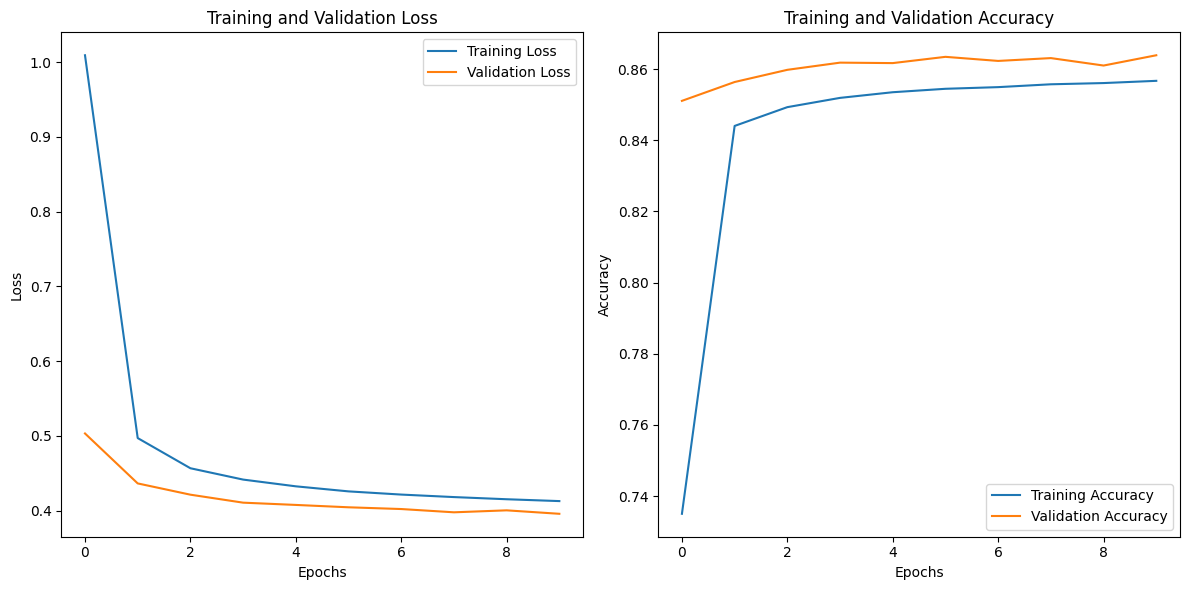

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8585 - loss: 0.3983
Test Loss: 0.3960239291191101
Test Accuracy: 0.8609166741371155


In [ ]:
def word_to_ints(word, tokenizer, max_len):
    word_seq = tokenizer.texts_to_sequences([word])  # Convert word to sequence of indices
    return pad_sequences(word_seq, maxlen=max_len, padding='post', truncating='post')

def predict_correct_word(misspelled_word, model, tokenizer, max_len):
    # Step 1: Preprocess the misspelled word
    X_input = word_to_ints(misspelled_word, tokenizer, max_len)

    # Step 2: Use the model to predict the word
    prediction = model.predict(X_input)

    # Step 3: Get the indices of the maximum values (predicted characters)
    predicted_seq = np.argmax(prediction, axis=-1)[0]  # Get the sequence of predicted character indices

    # Step 4: Convert predicted indices to characters
    int_to_char = {i: char for char, i in tokenizer.word_index.items()}
    int_to_char[0] = ''  # Map padding token (0) to an empty string

    # Step 5: Remove padding (0) and convert indices to a word
    predicted_word = ''.join([int_to_char[idx] for idx in predicted_seq if idx != 0])

    return predicted_word


misspelled_word = "thajt"  # Example misspelled word
predicted_word = predict_correct_word(misspelled_word, model, tokenizer, max_len)

print(f"Misspelled word: {misspelled_word}")
print(f"Predicted correct word: {predicted_word}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Misspelled word: thajt
Predicted correct word: mmmmmmmmmmmmmmmmmmmm
